In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt

airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [157]:
airbnb.info()
airbnb.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  object 
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  object 
 4   neighbourhood_full  10019 non-null  object 
 5   coordinates         10019 non-null  object 
 6   room_type           10019 non-null  object 
 7   price               9781 non-null   object 
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   object 
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  object 
dtypes: float6

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339


In [158]:

print("liczba naN w każdej kolumnie:")
print(airbnb.isnull().sum())

liczba naN w każdej kolumnie:
listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64


In [159]:
airbnb.sort_values(by='price', ascending=True).head(10)

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
4645,20933849,the best you can find,13709292,Qiuchi,"Manhattan, Murray Hill","(40.75091, -73.97596999999998)",Entire home/apt,0$,0,NaN,NaN,0,NaN,NaN,NaN,2018-04-21
8509,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,"Brooklyn, Bedford-Stuyvesant","(40.69023, -73.95428000000003)",Private room,0$,1,2018-01-06,0.05,28,3.778723,1.2,0.757915,2017-07-03
6566,19415314,"Girls only, cozy room one block from Times Square",47336995,Mario,"Manhattan, Hell's Kitchen","(40.75812, -73.98935)",Shared room,10$,2,2017-06-24,0.08,0,3.197329,2.4,0.643341,2016-12-19
2518,26235873,Voted #1 Airbnb In NYC,197169969,Maria,"Queens, Jamaica","(40.68939, -73.79885999999998)",Entire home/apt,10$,22,2019-07-06,1.76,332,4.957401,26.4,0.936053,2018-12-31
5838,24114389,"Very Spacious bedroom, steps from CENTRAL PARK.",180661875,Salim,"Manhattan, Upper West Side","(40.76844000000001, -73.98333000000002)",Private room,10$,2,2018-04-23,0.13,0,3.352248,2.4,0.612143,2017-10-18
6459,24412104,Cozy feel at home studio,91034542,Maureen,"Manhattan, Kips Bay","(40.74408, -73.97803)",Private room,10$,42,2019-06-30,2.87,2,4.888887,50.4,0.885943,2018-12-25
4784,17437106,Couch in Harlem Harvey Refugees only,33511962,Morgan,"Manhattan, Harlem","(40.81302, -73.95349)",Shared room,10$,0,NaN,NaN,0,NaN,NaN,NaN,2018-03-17
9807,35642891,Beautiful room in Bushwick,268138154,Julio,"Brooklyn, Bushwick","(40.6964, -73.91898)",Private room,10$,2,2019-06-18,2.00,0,4.674334,2.4,0.605253,2018-12-13
7573,21869057,Spacious 2-bedroom Apt in Heart of Greenpoint,11967922,Vishanti & Jeremy,"Brooklyn, Greenpoint","(40.72421, -73.95364000000002)",Entire home/apt,10$,93,2019-07-01,4.73,32,3.087759,111.6,0.620364,2018-12-26
2364,28213718,"""Sweet Home near to Bronx Zoo in Little Italy """,211638781,Adriana,"Bronx, Belmont","(40.85287, -73.88535999999998)",Private room,100$,36,2019-06-18,3.69,49,3.974512,43.2,0.702993,2018-12-13


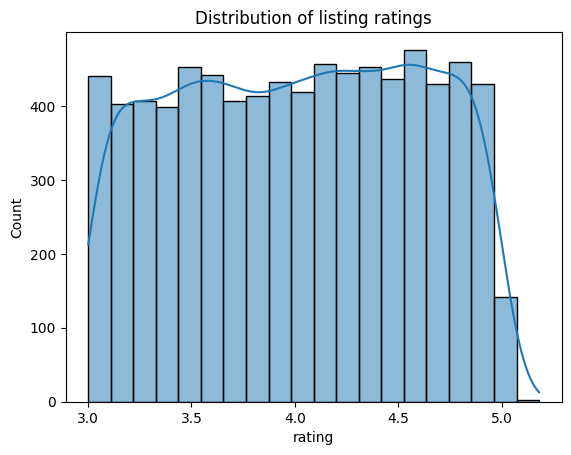

In [160]:
sns.histplot(airbnb['rating'], kde=True, bins = 20)
plt.title('Distribution of listing ratings')
plt.show()

In [161]:
airbnb['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Private', 'Shared room',
       'PRIVATE ROOM', 'home', '   Shared room      '], dtype=object)

In [162]:
airbnb[["latitude", "longitude"]] = (
    airbnb["coordinates"]
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.split(",", expand=True)
    .astype(float)
)
airbnb.drop(columns=['coordinates'], inplace=True)

airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15,40.70070,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354


In [163]:
airbnb['price'] = airbnb['price'].str.strip('$').astype(float)
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",Entire home/apt,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",Entire home/apt,150.0,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15,40.70070,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",Entire home/apt,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",Private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354


In [164]:
airbnb['price'].isna().sum()
avg = airbnb['price'].mean()
airbnb['price'] = airbnb['price'].fillna(avg)
airbnb['price'].isna().sum()


np.int64(0)

In [165]:
airbnb[['listing_added', 'last_review']] = airbnb[['listing_added', 'last_review']].apply(pd.to_datetime)
airbnb[['listing_added', 'last_review']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 10019 entries, 0 to 10018
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   listing_added  10019 non-null  datetime64[ns]
 1   last_review    7944 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 234.8 KB


In [166]:
airbnb['room_type'].unique()
airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip()
airbnb['room_type'].unique()


array(['private room', 'entire home/apt', 'private', 'shared room',
       'home'], dtype=object)

In [167]:
mappings = {'private room': 'Private Room',
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replace values and collapse data
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

array(['Private Room', 'Entire place', 'Shared room'], dtype=object)

In [168]:
airbnb['neighbourhood_full'].head()
airbnb[['borough', 'neighbourhood']] = airbnb['neighbourhood_full'].str.split(',', expand=True)
airbnb["borough"] = airbnb["borough"].str.strip()
airbnb["neighbourhood"] = airbnb["neighbourhood"].str.strip()
airbnb.drop(columns=['neighbourhood_full'], inplace=True)
airbnb.head()

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire place,150.0,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15,40.70070,-73.99517,Brooklyn,Brooklyn Heights
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Manhattan,Upper West Side
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354,Manhattan,Lower East Side


In [169]:
airbnb['rating'] = airbnb['rating'].astype(float)

airbnb[airbnb['rating'] > 5.0].shape[0]

3

In [170]:
airbnb['rating'].max()
airbnb['rating'] = airbnb['rating'].clip(upper=5)
airbnb['rating'].max()

np.float64(5.0)

<Axes: >

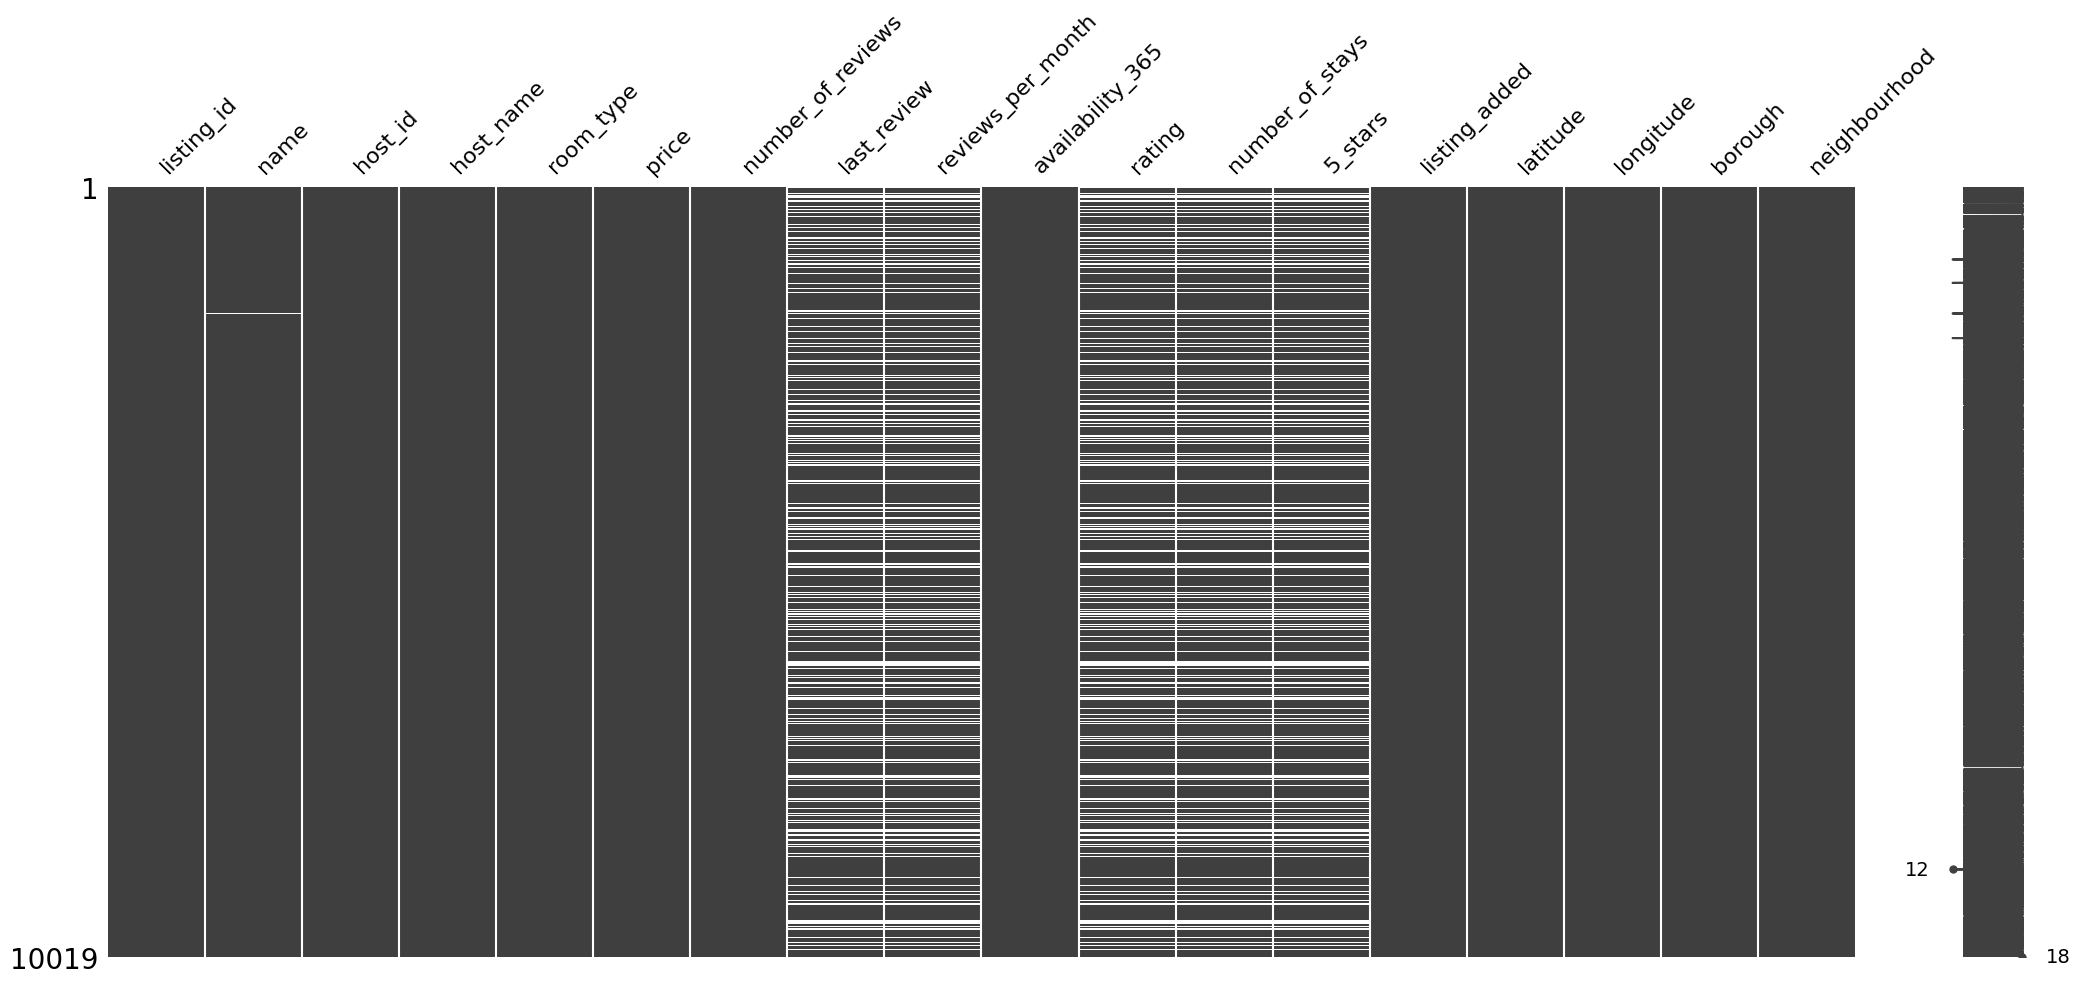

In [ ]:
msno.matrix(airbnb)

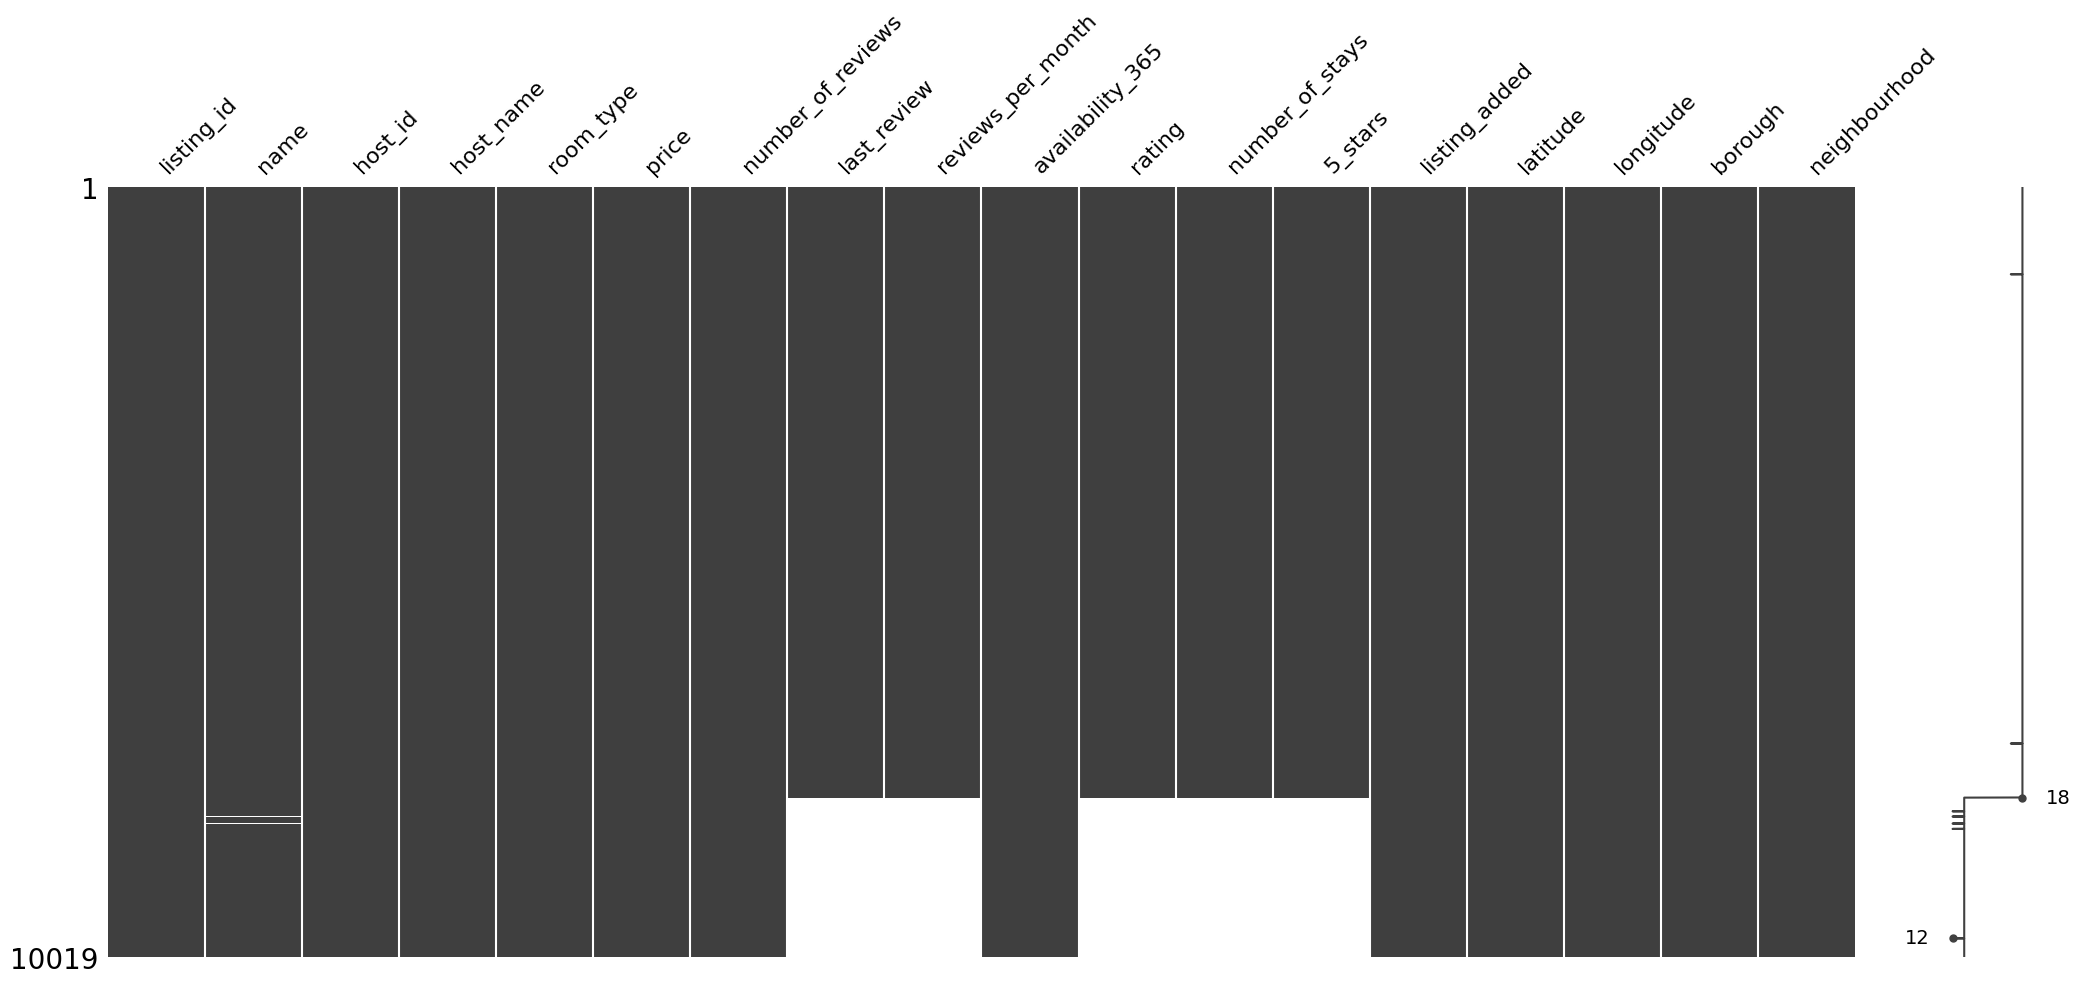

In [ ]:
msno.matrix(airbnb.sort_values(by = 'rating'))
plt.show()

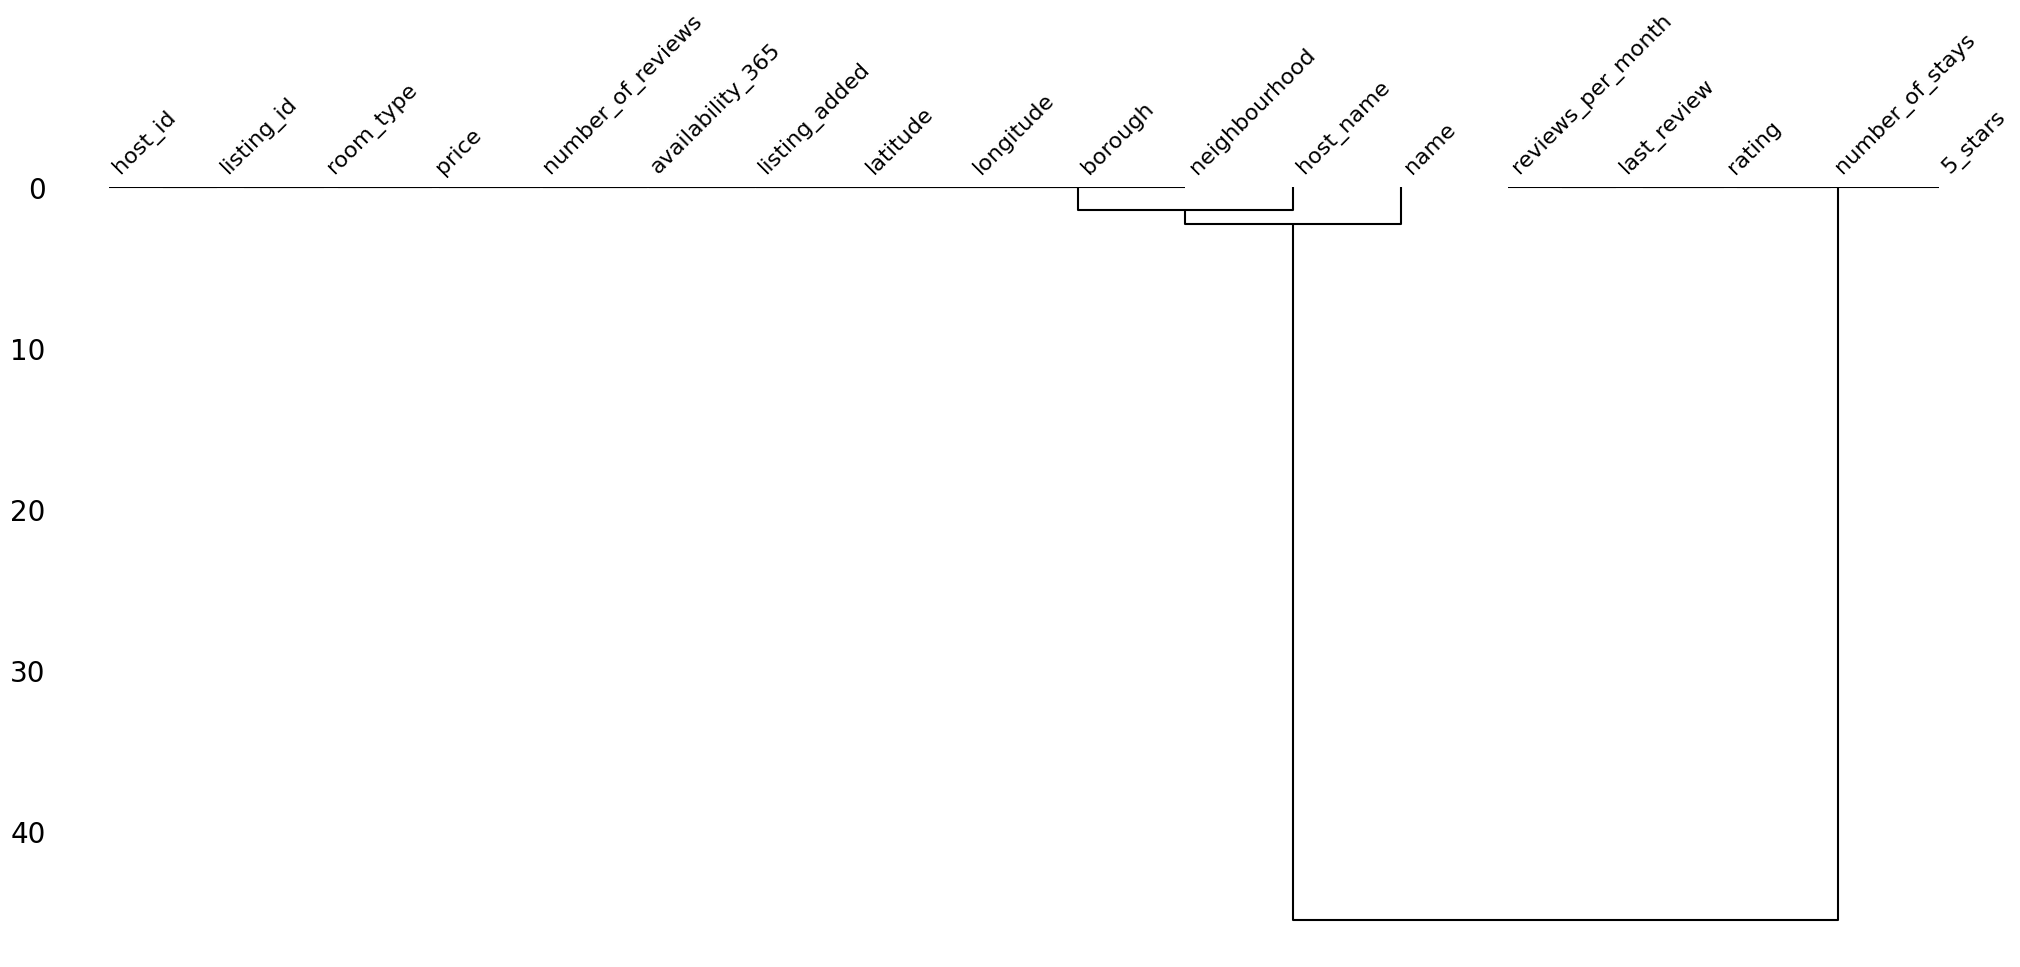

In [172]:
msno.dendrogram(airbnb)
plt.show()

<Axes: >

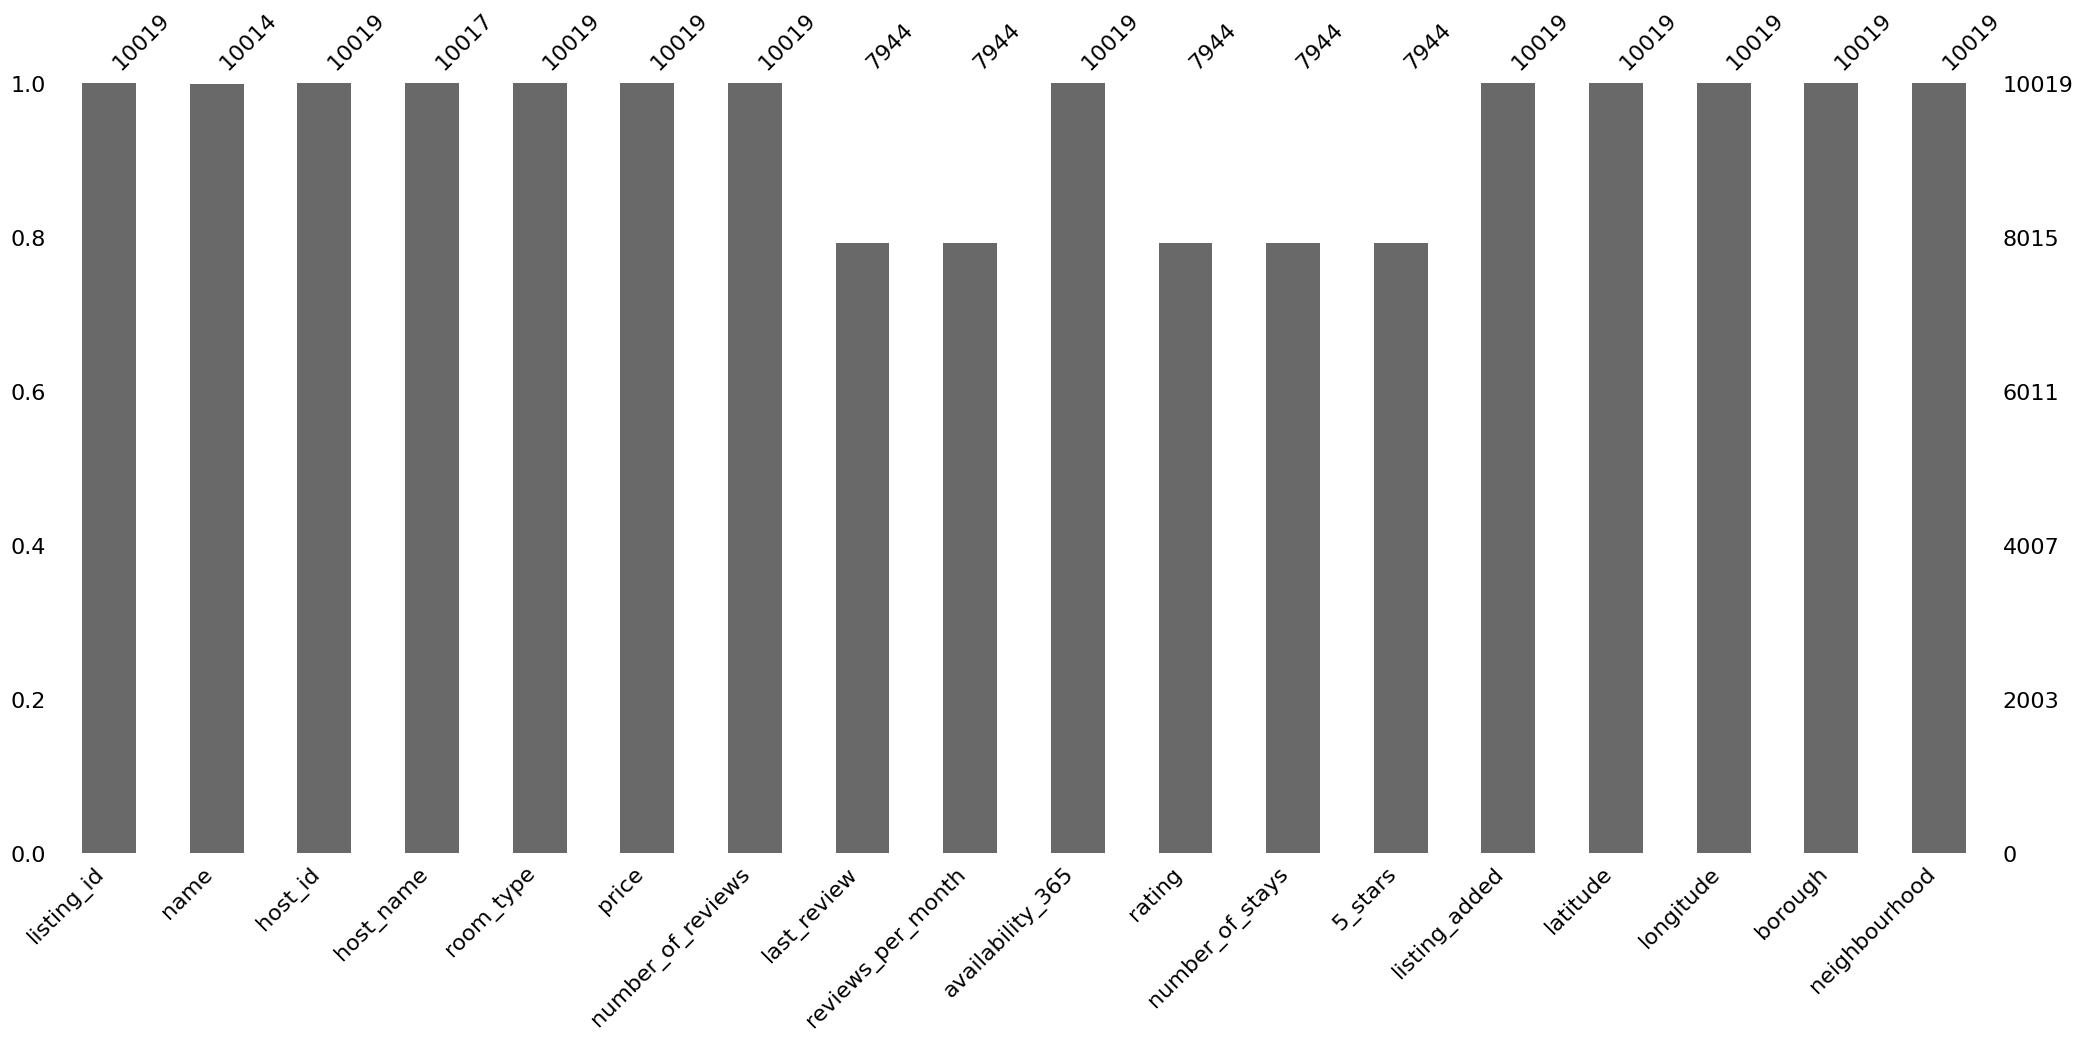

In [173]:
msno.bar(airbnb)

In [174]:
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,2.075000e+03,2.075000e+03,2075.000000,2075.0,0,0.0,2075.000000,0.0,0.0,0.0,2075,2075.000000,2075.000000
mean,2.274238e+07,8.022455e+07,190.633032,0.0,NaT,NaN,104.531566,NaN,NaN,NaN,2018-06-08 17:01:31.951807232,40.732074,-73.956771
min,6.358800e+04,1.475100e+04,0.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-02-03 00:00:00,40.527000,-74.209410
25%,1.232923e+07,1.224305e+07,70.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-04-05 00:00:00,40.697845,-73.985185
50%,2.345182e+07,4.040116e+07,120.000000,0.0,NaT,NaN,7.000000,NaN,NaN,NaN,2018-06-05 00:00:00,40.727790,-73.960940
75%,3.400364e+07,1.333498e+08,200.000000,0.0,NaT,NaN,211.000000,NaN,NaN,NaN,2018-08-13 00:00:00,40.763480,-73.939540
max,3.648724e+07,2.741034e+08,5250.000000,0.0,NaT,NaN,365.000000,NaN,NaN,NaN,2018-10-17 00:00:00,40.911690,-73.727310
std,1.123730e+07,8.663163e+07,312.642005,0.0,NaN,NaN,138.266525,NaN,NaN,NaN,NaN,0.051168,0.041065


In [175]:
airbnb[~airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,7.944000e+03,7.944000e+03,7944.000000,7944.000000,7944,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000,7944,7944.000000,7944.000000
mean,1.837100e+07,6.475548e+07,140.528056,28.326284,2018-10-07 03:30:05.438066432,1.353894,114.309290,4.014422,33.991541,0.718599,2018-04-03 15:56:11.601208320,40.728325,-73.950642
min,3.831000e+03,2.787000e+03,0.000000,1.000000,2011-03-28 00:00:00,0.010000,0.000000,3.000633,1.200000,0.600026,2010-09-22 00:00:00,40.508680,-74.239860
25%,8.970241e+06,7.137797e+06,69.000000,3.000000,2018-07-16 00:00:00,0.200000,0.000000,3.520443,3.600000,0.655576,2018-01-10 00:00:00,40.688567,-73.982152
50%,1.928118e+07,2.949374e+07,109.000000,9.000000,2019-05-19 00:00:00,0.710000,54.000000,4.027965,10.800000,0.709768,2018-11-13 00:00:00,40.721785,-73.954415
75%,2.789420e+07,1.016715e+08,169.000000,32.000000,2019-06-23 00:00:00,2.000000,229.000000,4.516378,38.400000,0.763978,2018-12-18 00:00:00,40.763360,-73.934930
max,3.641363e+07,2.733615e+08,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00,40.913060,-73.719280
std,1.069161e+07,7.608428e+07,161.696882,46.741066,NaN,1.615380,129.781153,0.574998,56.089279,0.079978,NaN,0.055482,0.047013


In [176]:
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0})
is_rated = np.where(airbnb['rating'].isna() == True, 0, 1)
airbnb['is_rated'] = is_rated

In [177]:
airbnb[airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,is_rated
count,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [178]:
airbnb[~airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,is_rated
count,1.001900e+04,1.001900e+04,10019.000000,10019.000000,7944,10019.000000,10019.000000,7944.000000,10019.000000,10019.000000,10019,10019.000000,10019.000000,10019.000000
mean,1.927634e+07,6.795923e+07,150.905122,22.459727,2018-10-07 03:30:05.438066432,1.073493,112.284260,4.014422,26.951672,0.569772,2018-04-17 08:13:07.623515392,40.729102,-73.951911,0.792894
min,3.831000e+03,2.787000e+03,0.000000,0.000000,2011-03-28 00:00:00,0.000000,0.000000,3.000633,0.000000,0.000000,2010-09-22 00:00:00,40.508680,-74.239860,0.000000
25%,9.674772e+06,7.910880e+06,70.000000,1.000000,2018-07-16 00:00:00,0.040000,0.000000,3.520443,1.200000,0.611660,2018-03-08 00:00:00,40.689880,-73.982845,1.000000
50%,2.007030e+07,3.165167e+07,110.000000,5.000000,2019-05-19 00:00:00,0.370000,44.000000,4.027965,6.000000,0.681930,2018-09-09 00:00:00,40.723010,-73.955430,1.000000
75%,2.933864e+07,1.074344e+08,175.000000,22.000000,2019-06-23 00:00:00,1.550000,226.000000,4.516378,26.400000,0.750088,2018-12-14 00:00:00,40.763390,-73.936065,1.000000
max,3.648724e+07,2.741034e+08,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00,40.913060,-73.719280,1.000000
std,1.095056e+07,7.863106e+07,203.417189,43.173896,NaN,1.539481,131.636043,0.574998,51.808675,0.299795,NaN,0.054636,0.045910,0.405253


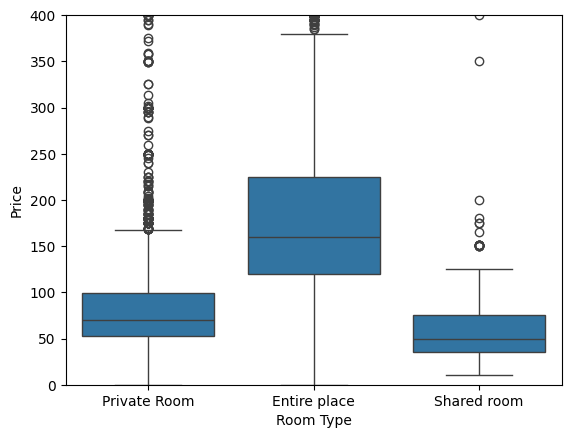

In [179]:
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

In [180]:
airbnb.groupby('room_type')['price'].median()

room_type
Entire place    160.0
Private Room     70.0
Shared room      50.0
Name: price, dtype: float64

In [182]:
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared Room'), 'price'] = 50.0
airbnb['price'].isna().sum()

np.int64(0)

In [183]:
airbnb.isna().sum()

listing_id              0
name                    5
host_id                 0
host_name               2
room_type               0
price                   0
number_of_reviews       0
last_review          2075
reviews_per_month       0
availability_365        0
rating               2075
number_of_stays         0
5_stars                 0
listing_added           0
latitude                0
longitude               0
borough                 0
neighbourhood           0
is_rated                0
dtype: int64

In [184]:
airbnb['rating'].isna().sum()

np.int64(2075)